In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import make_scorer, matthews_corrcoef, f1_score, balanced_accuracy_score, precision_score, recall_score, precision_recall_curve, average_precision_score, roc_curve, auc

In [5]:
# 1. Load data
df = pd.read_csv('ppi.csv')

In [6]:
# 2. Splitting 
unique_proteins = df['uniprot_id'].unique()
train_val_ids, test_ids = train_test_split(unique_proteins, test_size=0.20, random_state=22)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=23)
train_data = df[df['uniprot_id'].isin(train_ids)]

In [7]:
# 3. MODELS BASE + WM
metadata = ['Unnamed: 0', 'domain', 'aa_ProtPosition', 'uniprot_id', 'Rlength', 'sequence', 'normalized_length', 'p_interface']

# Base only
base_features = [
    'normalized_abs_surf_acc', 'normalized_hydropathy_index', 'rel_surf_acc',
    'prob_sheet', 'prob_helix', 'prob_coil'
] + [c for c in df.columns if c.startswith('pssm_') and '_wm_' not in c]

#Base + Windows
feature_sets = {
    "Model 1: Base Only": base_features,
    "Model 2: Base + WM3": base_features + [c for c in df.columns if c.startswith('3_wm_')],
    "Model 3: Base + WM5": base_features + [c for c in df.columns if c.startswith('5_wm_')],
    "Model 4: Base + WM7": base_features + [c for c in df.columns if c.startswith('7_wm_')],
    "Model 5: Base + WM9": base_features + [c for c in df.columns if c.startswith('9_wm_')]
}

In [8]:
# 4. Imbalance Configurations 
ros = RandomOverSampler(random_state=44)
rus = RandomUnderSampler(random_state=33)
y_train = train_data['p_interface']
xgb_ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

configs = [
    ("RF (Undersampled)", Pipeline([
        ('resampler', rus), 
        ('model', RandomForestClassifier(
            n_estimators=400,           
            max_depth=None,           
            max_features='sqrt',        
            min_samples_split=2,        
            random_state=66, 
            n_jobs=-1
        ))
    ])),
    
    ("XGBoost (Class Weight)", XGBClassifier(
        scale_pos_weight=xgb_ratio, 
        learning_rate=0.01,            
        n_estimators=500,               
        max_depth=10,                  
        subsample=0.8,                  
        colsample_bytree=0.8,           
        eval_metric='logloss', 
        random_state=100
    ))
]

In [9]:
# 5. Metrics & CV
scoring = {
    'MCC': make_scorer(matthews_corrcoef),
    'F1': make_scorer(f1_score, zero_division=0),
    'ROC-AUC': 'roc_auc',
    'Bal.Acc': make_scorer(balanced_accuracy_score),
    'Precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)

final_results = []

saved_files_registry = {} 
f1_scores_by_config = {}


for model_name, features in feature_sets.items():
    print(f"Testing {model_name}...")
    X_train_sub = train_data[features]
    y_train = train_data['p_interface']
    
    for config_name, clf in configs:
        y_probas = cross_val_predict(clf, X_train_sub, y_train, cv=cv, method='predict_proba', n_jobs=-1)
        probs = y_probas[:, 1]
        
        safe_model = model_name.replace(" ", "_").replace(":", "").replace("+", "plus")
        safe_config = config_name.replace(" ", "_").replace("(", "").replace(")", "")
        filename = f"{safe_model}_{safe_config}.csv"
        file_path = os.path.join(output_dir, filename)
        
        pd.DataFrame({'y_true': y_train, 'y_prob': probs}).to_csv(file_path, index=False)
        
        if config_name not in saved_files_registry:
            saved_files_registry[config_name] = []
        saved_files_registry[config_name].append((model_name, file_path))
        
        scores = cross_validate(clf, X_train_sub, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        final_results.append({
            'Model': model_name, 'Config': config_name,
            'MCC': np.mean(scores['test_MCC']).round(3),
            'F1': np.mean(scores['test_F1']).round(3),
            'AUC': np.mean(scores['test_ROC-AUC']).round(3),
            'Bal.Acc': np.mean(scores['test_Bal.Acc']).round(3),    
            'Precision': np.mean(scores['test_Precision']).round(3), 
            'Recall': np.mean(scores['test_Recall']).round(3)

        })
        # save fold-level F1 scores for statistical test
        f1_scores_by_config[f"{model_name}_{config_name}"] = scores['test_F1']


print("\n--- DONE: Files saved to model_outputs/ ---")

Testing Model 1: Base Only...
Testing Model 2: Base + WM3...
Testing Model 3: Base + WM5...
Testing Model 4: Base + WM7...
Testing Model 5: Base + WM9...

--- DONE: Files saved to model_outputs/ ---


In [20]:
print(f1_scores_by_config.keys())


dict_keys(['Model 1: Base Only_RF (Undersampled)', 'Model 1: Base Only_XGBoost (Class Weight)', 'Model 2: Base + WM3_RF (Undersampled)', 'Model 2: Base + WM3_XGBoost (Class Weight)', 'Model 3: Base + WM5_RF (Undersampled)', 'Model 3: Base + WM5_XGBoost (Class Weight)', 'Model 4: Base + WM7_RF (Undersampled)', 'Model 4: Base + WM7_XGBoost (Class Weight)', 'Model 5: Base + WM9_RF (Undersampled)', 'Model 5: Base + WM9_XGBoost (Class Weight)'])


In [21]:
# save fold-level F1 scores for statistical test
if config_name == "RandomForest":
    rf_f1_scores = scores['test_F1']

if config_name == "XGBoost":
    xgb_f1_scores = scores['test_F1']


In [11]:
# Summary table
results_df = pd.DataFrame(final_results)
print("\n--- FINAL CROSS-VALIDATION RESULTS ---")
print(results_df.to_string(index=False))


--- FINAL CROSS-VALIDATION RESULTS ---
              Model                 Config   MCC    F1   AUC  Bal.Acc  Precision  Recall
 Model 1: Base Only      RF (Undersampled) 0.119 0.254 0.622    0.592      0.160   0.611
 Model 1: Base Only XGBoost (Class Weight) 0.098 0.221 0.622    0.557      0.189   0.265
Model 2: Base + WM3      RF (Undersampled) 0.151 0.272 0.664    0.616      0.171   0.658
Model 2: Base + WM3 XGBoost (Class Weight) 0.134 0.241 0.675    0.570      0.229   0.254
Model 3: Base + WM5      RF (Undersampled) 0.190 0.294 0.697    0.647      0.185   0.713
Model 3: Base + WM5 XGBoost (Class Weight) 0.168 0.278 0.710    0.595      0.244   0.323
Model 4: Base + WM7      RF (Undersampled) 0.215 0.308 0.726    0.666      0.194   0.743
Model 4: Base + WM7 XGBoost (Class Weight) 0.206 0.314 0.739    0.623      0.258   0.400
Model 5: Base + WM9      RF (Undersampled) 0.231 0.317 0.746    0.678      0.200   0.765
Model 5: Base + WM9 XGBoost (Class Weight) 0.253 0.354 0.765    0.655 

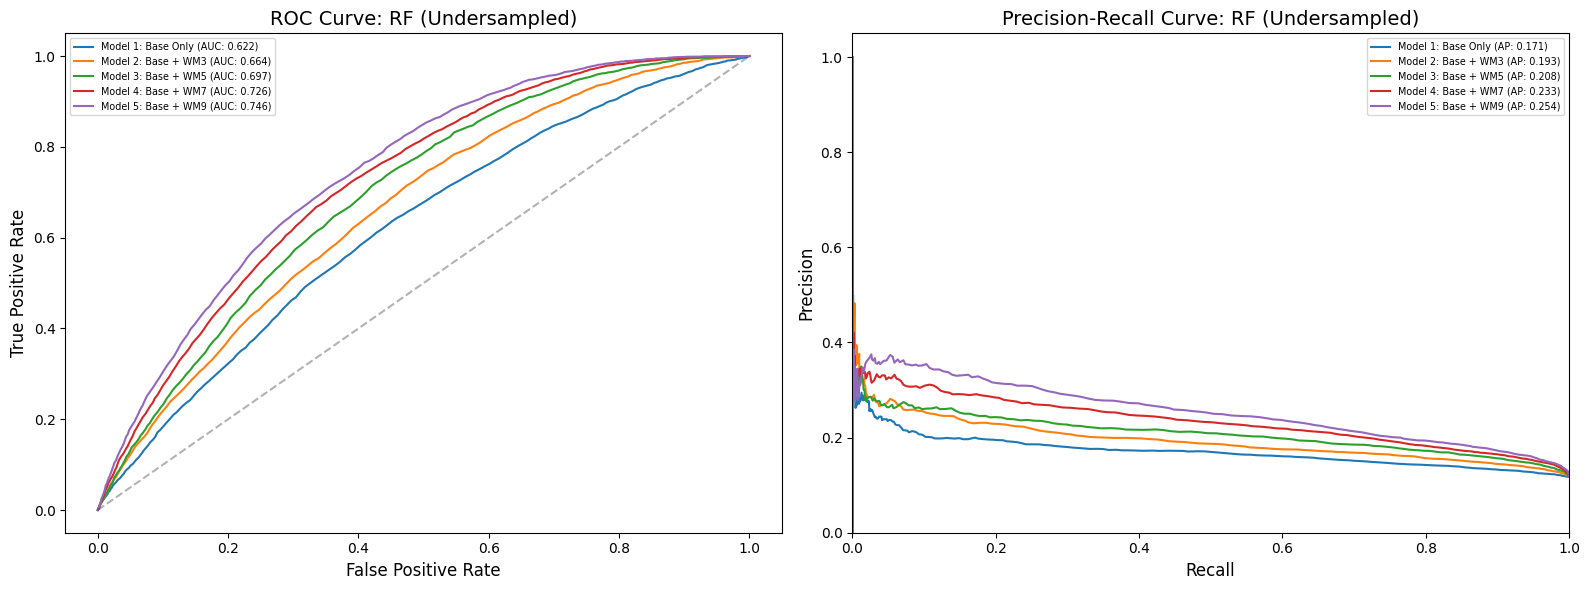

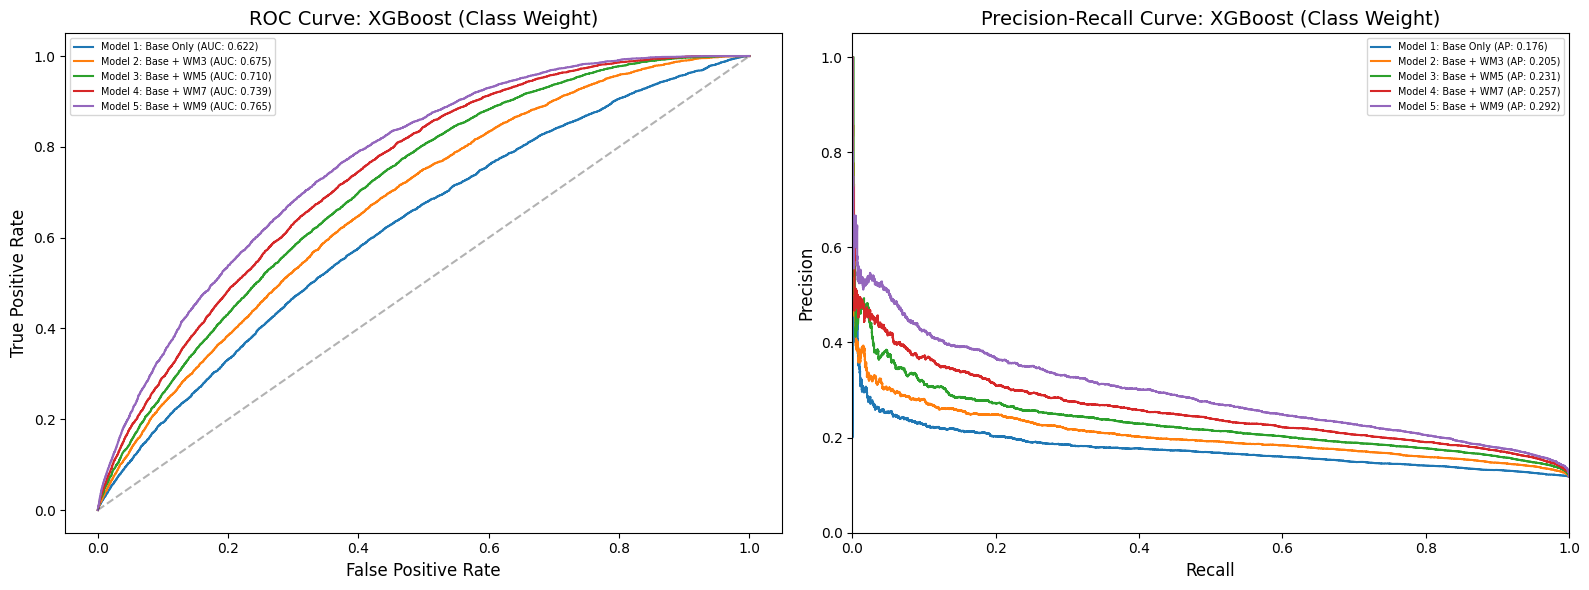

In [12]:
for config_name, file_info_list in saved_files_registry.items():
    if config_name not in ["RF (Undersampled)", "XGBoost (Class Weight)"]:
        continue
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for model_label, path in file_info_list:
        if not os.path.exists(path):
            continue
            
        data = pd.read_csv(path)
        y_true, y_prob = data['y_true'], data['y_prob']

        # 1. ROC Calculation
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, label=f'{model_label} (AUC: {auc(fpr, tpr):.3f})')
        
        # 2. PR Calculation
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(recall, precision, label=f'{model_label} (AP: {average_precision_score(y_true, y_prob):.3f})')

    # ROC
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_title(f'ROC Curve: {config_name}', fontsize=14)
    ax1.set_xlabel('False Positive Rate', fontsize=12) 
    ax1.set_ylabel('True Positive Rate', fontsize=12)  
    ax1.legend(fontsize='x-small')
    
    # PR
    ax2.set_title(f'Precision-Recall Curve: {config_name}', fontsize=14)
    ax2.set_xlabel('Recall', fontsize=12)             
    ax2.set_ylabel('Precision', fontsize=12)         
    ax2.set_xlim([0, 1.0])
    ax2.set_ylim([0, 1.05])
    ax2.legend(fontsize='x-small')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Statistical Test: Paired t-test on F1 scores
from scipy.stats import ttest_rel

pairs = [
("Model 1: Base Only_RF (Undersampled)", "Model 1: Base Only_XGBoost (Class Weight)"),
("Model 2: Base + WM3_RF (Undersampled)", "Model 2: Base + WM3_XGBoost (Class Weight)"),
("Model 3: Base + WM5_RF (Undersampled)", "Model 3: Base + WM5_XGBoost (Class Weight)"),
("Model 4: Base + WM7_RF (Undersampled)", "Model 4: Base + WM7_XGBoost (Class Weight)"),
("Model 5: Base + WM9_RF (Undersampled)", "Model 5: Base + WM9_XGBoost (Class Weight)")
]

for rf_key, xgb_key in pairs:
    
    rf_f1 = f1_scores_by_config[rf_key]
    xgb_f1 = f1_scores_by_config[xgb_key]

    t_stat, p_value = ttest_rel(rf_f1, xgb_f1)

    print("\nComparison:", rf_key.split("_")[0])
    print("RF F1:", rf_f1)
    print("XGB F1:", xgb_f1)
    print("p-value:", round(p_value,4))
import pandas as pd
from scipy.stats import ttest_rel
import numpy as np

rows = []

pairs = [
("Model 1: Base Only_RF (Undersampled)", "Model 1: Base Only_XGBoost (Class Weight)"),
("Model 2: Base + WM3_RF (Undersampled)", "Model 2: Base + WM3_XGBoost (Class Weight)"),
("Model 3: Base + WM5_RF (Undersampled)", "Model 3: Base + WM5_XGBoost (Class Weight)"),
("Model 4: Base + WM7_RF (Undersampled)", "Model 4: Base + WM7_XGBoost (Class Weight)"),
("Model 5: Base + WM9_RF (Undersampled)", "Model 5: Base + WM9_XGBoost (Class Weight)")
]

for rf_key, xgb_key in pairs:

    rf_f1 = f1_scores_by_config[rf_key]
    xgb_f1 = f1_scores_by_config[xgb_key]

    t_stat, p_value = ttest_rel(rf_f1, xgb_f1)

    rows.append({
        "Model": rf_key.split("_")[0],
        "RF F1 (mean)": round(np.mean(rf_f1), 3),
        "XGBoost F1 (mean)": round(np.mean(xgb_f1), 3),
        "p-value": round(p_value, 4),
        "Better Model": "RF" if np.mean(rf_f1) > np.mean(xgb_f1) else "XGBoost"
    })

results_table = pd.DataFrame(rows)
results_table






Comparison: Model 1: Base Only
RF F1: [0.25       0.25731261 0.25070159 0.25991792 0.25189961]
XGB F1: [0.19905213 0.21932584 0.23313447 0.23055556 0.22057461]
p-value: 0.0036

Comparison: Model 2: Base + WM3
RF F1: [0.27003444 0.27295512 0.27276888 0.27939464 0.26440678]
XGB F1: [0.21806521 0.23632611 0.24817518 0.24096386 0.26109128]
p-value: 0.0192

Comparison: Model 3: Base + WM5
RF F1: [0.28286112 0.29173202 0.30006882 0.30041341 0.29347826]
XGB F1: [0.26573427 0.27835052 0.2754902  0.28266149 0.28787879]
p-value: 0.0072

Comparison: Model 4: Base + WM7
RF F1: [0.3054325  0.30653266 0.30902461 0.31652989 0.30272953]
XGB F1: [0.31002527 0.31260647 0.32087511 0.31640449 0.3088672 ]
p-value: 0.0407

Comparison: Model 5: Base + WM9
RF F1: [0.31831972 0.31542857 0.31904869 0.3205068  0.31197263]
XGB F1: [0.35129402 0.34577114 0.36880034 0.35343384 0.34834325]
p-value: 0.0005


,Model,RF F1 (mean),XGBoost F1 (mean),p-value,Better Model
0,Model 1: Base Only,0.254,0.221,0.0036,RF
1,Model 2: Base + WM3,0.272,0.241,0.0192,RF
2,Model 3: Base + WM5,0.294,0.278,0.0072,RF
3,Model 4: Base + WM7,0.308,0.314,0.0407,XGBoost
4,Model 5: Base + WM9,0.317,0.354,0.0005,XGBoost
